# Module 11: The Ideal Role Player Profile

Not every roster spot is for a star. But the Yankees' biggest mistake wasn't failing to find stars — it was filling the gaps with **extremes**. Joey Gallo: 40% K rate, 18.5% barrel rate, nothing in between. IKF: 1.2% barrel rate, .650 OPS, can't hurt you. Contenders don't build lineups like this.

The 2024 World Series Dodgers had **5 complete hitters**. The 2023 Rangers had 4. The 2022 Astros had 5. The Yankees? 1-2 at best.

This notebook asks: **What does the ideal complementary hitter look like for the Yankees?** Not a star — a role player who rounds out the lineup. A balanced hitter who uses the whole field, makes contact, gets on base, and runs the bases. Yankee Stadium's short porch is a bonus, not a strategy.

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from fire_fishman.data.statcast import get_statcast_pitches, get_batting_stats
from fire_fishman.features.batted_ball import classify_hit_directions

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 7)

/Users/wks/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# Load FanGraphs batting stats for 2021-2025
batting_dfs = []
for year in range(2021, 2026):
    df = get_batting_stats(year)
    df["Season"] = year
    batting_dfs.append(df)

batting = pd.concat(batting_dfs, ignore_index=True)
print(f"Total player-seasons: {len(batting)}")

# Filter to qualified hitters (300+ PA) for meaningful sample
qualified = batting[batting["PA"] >= 300].copy()
print(f"Qualified (300+ PA): {len(qualified)}")

Pulling FanGraphs batting stats for 2025...


Cached 537 player-seasons to /Users/wks/Documents/Projects/fire_fishman/notebooks/../src/fire_fishman/data/cache/batting_stats_2025.parquet
Total player-seasons: 2708
Qualified (300+ PA): 1395


## 1. Defining the Extremes

First, let's quantify what went wrong. The Yankees oscillated between two archetypes:

- **The Slugger Extreme** (Gallo type): High barrel rate, high K%, low contact, low batting average. All-or-nothing.
- **The Contact Extreme** (IKF type): Low K%, low barrel rate, no power, no walks. Can't hurt you.

Contenders build rosters with **complete hitters** who barrel the ball AND make contact AND take walks.

In [3]:
# Define complete hitter profile
# A "complete" hitter has: barrel rate >= 7%, K% <= 25%, BB% >= 8%, wOBA >= .310
# These are not star numbers -- they're baseline competence

if "Barrel%" in qualified.columns:
    barrel_col = "Barrel%"
elif "Barrel" in qualified.columns:
    barrel_col = "Barrel"
else:
    # Try to find it
    barrel_candidates = [c for c in qualified.columns if "barrel" in c.lower()]
    barrel_col = barrel_candidates[0] if barrel_candidates else None
    print(f"Found barrel column: {barrel_col}")

# Identify K% and BB% columns
k_col = "K%" if "K%" in qualified.columns else "SO%"
bb_col = "BB%" if "BB%" in qualified.columns else None

print(f"Using columns: barrel={barrel_col}, K={k_col}, BB={bb_col}")

# Ensure numeric
for col in [barrel_col, k_col, bb_col, "wOBA"]:
    if col and col in qualified.columns:
        qualified[col] = pd.to_numeric(qualified[col], errors="coerce")

# Handle percentage format (some FanGraphs exports use 0-1, some use 0-100)
if qualified[k_col].median() > 1:  # likely 0-100 format
    qualified[k_col] = qualified[k_col] / 100
if bb_col and qualified[bb_col].median() > 1:
    qualified[bb_col] = qualified[bb_col] / 100
if barrel_col and qualified[barrel_col].median() > 1:
    qualified[barrel_col] = qualified[barrel_col] / 100

Using columns: barrel=Barrel%, K=K%, BB=BB%


In [4]:
# Classify hitter types
def classify_hitter(row):
    barrel = row.get(barrel_col, np.nan) if barrel_col else np.nan
    k_rate = row.get(k_col, np.nan)
    bb_rate = row.get(bb_col, np.nan) if bb_col else np.nan
    woba = row.get("wOBA", np.nan)

    if pd.isna(barrel) or pd.isna(k_rate):
        return "unknown"

    # Slugger extreme: high power, high K
    if barrel >= 0.10 and k_rate >= 0.30:
        return "slugger_extreme"

    # Contact extreme: low power, low K but also low walks/production
    if barrel < 0.05 and k_rate <= 0.18 and (woba < 0.310 if not pd.isna(woba) else True):
        return "contact_extreme"

    # Complete hitter: balanced profile
    if (barrel >= 0.07 and k_rate <= 0.25 and
        (bb_rate >= 0.08 if not pd.isna(bb_rate) else True) and
        (woba >= 0.310 if not pd.isna(woba) else True)):
        return "complete"

    return "other"

qualified["hitter_type"] = qualified.apply(classify_hitter, axis=1)

print("Hitter Type Distribution (2021-2025, 300+ PA):")
print(qualified["hitter_type"].value_counts())
print(f"\nComplete hitters per team-season: {qualified[qualified['hitter_type'] == 'complete'].groupby('Season').size().mean():.0f} across 30 teams")
print(f"  = ~{qualified[qualified['hitter_type'] == 'complete'].groupby('Season').size().mean() / 30:.1f} per team")

Hitter Type Distribution (2021-2025, 300+ PA):
hitter_type
other              924
complete           289
contact_extreme     93
slugger_extreme     89
Name: count, dtype: int64

Complete hitters per team-season: 58 across 30 teams
  = ~1.9 per team


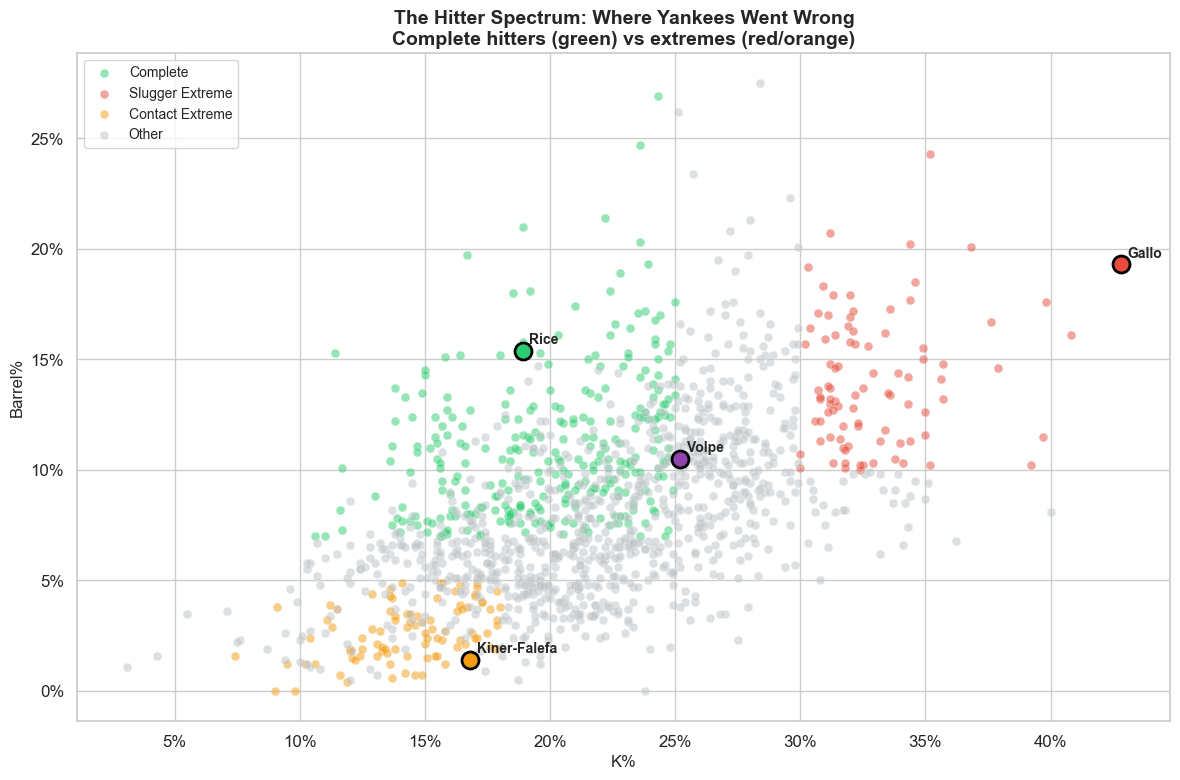

In [5]:
# Figure 1: The spectrum of hitter types
fig, ax = plt.subplots(figsize=(12, 8))

type_colors = {
    "complete": "#2ecc71",
    "slugger_extreme": "#e74c3c",
    "contact_extreme": "#f39c12",
    "other": "#bdc3c7",
}

for htype, color in type_colors.items():
    mask = qualified["hitter_type"] == htype
    subset = qualified[mask]
    if barrel_col and len(subset) > 0:
        ax.scatter(
            subset[k_col], subset[barrel_col],
            c=color, label=htype.replace("_", " ").title(),
            s=40, alpha=0.5, edgecolors="white", linewidth=0.3,
        )

# Label notable Yankees examples if in data
notable = {
    "Joey Gallo": "#e74c3c",
    "Isiah Kiner-Falefa": "#f39c12",
    "Ben Rice": "#2ecc71",
    "Anthony Volpe": "#8e44ad",
}
for name, color in notable.items():
    player = qualified[qualified["Name"] == name]
    if len(player) > 0 and barrel_col:
        row = player.iloc[-1]  # most recent season
        ax.scatter(row[k_col], row[barrel_col], c=color, s=150,
                  edgecolors="black", linewidth=2, zorder=5)
        ax.annotate(name.split()[-1], (row[k_col], row[barrel_col]),
                   fontsize=10, fontweight="bold", xytext=(5, 5),
                   textcoords="offset points")

ax.set_xlabel("K%", fontsize=12)
ax.set_ylabel("Barrel%", fontsize=12)
ax.set_title("The Hitter Spectrum: Where Yankees Went Wrong\nComplete hitters (green) vs extremes (red/orange)",
             fontsize=14, fontweight="bold")
ax.legend(loc="upper left", fontsize=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

plt.tight_layout()
plt.savefig("../outputs/figures/hitter_spectrum.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. What Contenders Look Like

How many complete hitters did recent World Series champions carry?

In [6]:
# World Series winners and runners-up
ws_teams = {
    2021: {"winner": "ATL", "loser": "HOU"},
    2022: {"winner": "HOU", "loser": "PHI"},
    2023: {"winner": "TEX", "loser": "ARI"},
    2024: {"winner": "LAD", "loser": "NYY"},
}

print("COMPLETE HITTERS ON WS TEAMS")
print("=" * 60)
for year, teams in ws_teams.items():
    year_qual = qualified[qualified["Season"] == year]
    for role, team_abbr in teams.items():
        team_hitters = year_qual[year_qual["Team"] == team_abbr]
        complete = team_hitters[team_hitters["hitter_type"] == "complete"]
        slugger = team_hitters[team_hitters["hitter_type"] == "slugger_extreme"]
        contact = team_hitters[team_hitters["hitter_type"] == "contact_extreme"]
        print(f"\n{year} {role.upper()}: {team_abbr}")
        print(f"  Complete hitters: {len(complete)}")
        if len(complete) > 0:
            for _, p in complete.iterrows():
                print(f"    {p['Name']}: {p.get('wOBA', 'N/A'):.3f} wOBA, "
                      f"{p[k_col]:.1%} K%, {p.get(barrel_col, 'N/A'):.1%} Barrel%" if barrel_col else "")
        print(f"  Slugger extremes: {len(slugger)}")
        print(f"  Contact extremes: {len(contact)}")

COMPLETE HITTERS ON WS TEAMS

2021 WINNER: ATL
  Complete hitters: 2
    Freddie Freeman: 0.379 wOBA, 15.4% K%, 11.5% Barrel%
    Ronald Acuna Jr.: 0.412 wOBA, 23.6% K%, 20.3% Barrel%
  Slugger extremes: 0
  Contact extremes: 0

2021 LOSER: HOU
  Complete hitters: 3
    Carlos Correa: 0.364 wOBA, 18.1% K%, 9.4% Barrel%
    Kyle Tucker: 0.383 wOBA, 15.9% K%, 11.6% Barrel%
    Yordan Alvarez: 0.369 wOBA, 24.2% K%, 15.9% Barrel%
  Slugger extremes: 1
  Contact extremes: 0

2022 WINNER: HOU
  Complete hitters: 4
    Jose Altuve: 0.397 wOBA, 14.4% K%, 7.7% Barrel%
    Yordan Alvarez: 0.427 wOBA, 18.9% K%, 21.0% Barrel%
    Alex Bregman: 0.358 wOBA, 11.7% K%, 7.3% Barrel%
    Kyle Tucker: 0.348 wOBA, 15.6% K%, 10.1% Barrel%
  Slugger extremes: 0
  Contact extremes: 1

2022 LOSER: PHI
  Complete hitters: 1
    Bryce Harper: 0.369 wOBA, 20.4% K%, 12.8% Barrel%
  Slugger extremes: 0
  Contact extremes: 0

2023 WINNER: TEX
  Complete hitters: 3
    Corey Seager: 0.419 wOBA, 16.4% K%, 15.2% Barre

## 3. The Ideal Complementary Profile

Given Yankee Stadium's dimensions and the typical Yankees core (1-2 stars + 2-3 solid regulars), what should the remaining roster spots look like?

The ideal role player:
- **Makes contact** (K% < 22%): Can move runners, put pressure on defense
- **Has some barrel** (Barrel% > 6%): Not an empty batting average
- **Takes walks** (BB% > 8%): Gets on base, sees pitches, works counts
- **Runs the bases** (BsR > 0): Doesn't clog the bases, can take extra bags
- **Uses the whole field**: Not one-dimensional in any direction

This is the **anti-extreme**. Not a star profile, but a lineup-rounding contributor.

In [7]:
# Define the ideal role player profile
# Not star numbers -- just competent, balanced production
role_player_criteria = {
    k_col: ("<=", 0.22),
    bb_col: (">=", 0.08) if bb_col else None,
    "wOBA": (">=", 0.300),
}
if barrel_col:
    role_player_criteria[barrel_col] = (">=", 0.06)

# Filter for role player profile
role_players = qualified.copy()
for col, criteria in role_player_criteria.items():
    if criteria is None or col not in role_players.columns:
        continue
    direction, threshold = criteria
    if direction == "<=":
        role_players = role_players[role_players[col] <= threshold]
    elif direction == ">=":
        role_players = role_players[role_players[col] >= threshold]

# Exclude obvious stars (top-tier production)
role_players = role_players[role_players["wOBA"] < 0.380]

print(f"Players matching ideal role player profile: {len(role_players)} player-seasons")
print(f"  ({len(role_players) / len(qualified) * 100:.1f}% of qualified hitters)")

# Show average profile
print("\nAverage Ideal Role Player Profile:")
profile_cols = [k_col, bb_col, barrel_col, "wOBA", "wRC+", "AVG", "OBP", "SLG"]
profile_cols = [c for c in profile_cols if c and c in role_players.columns]
for col in profile_cols:
    val = role_players[col].mean()
    if col in [k_col, bb_col, barrel_col]:
        print(f"  {col}: {val:.1%}")
    else:
        print(f"  {col}: {val:.3f}")

Players matching ideal role player profile: 204 player-seasons
  (14.6% of qualified hitters)

Average Ideal Role Player Profile:
  K%: 18.1%
  BB%: 10.4%
  Barrel%: 9.1%
  wOBA: 0.341
  wRC+: 118.794
  AVG: 0.260
  OBP: 0.344
  SLG: 0.445


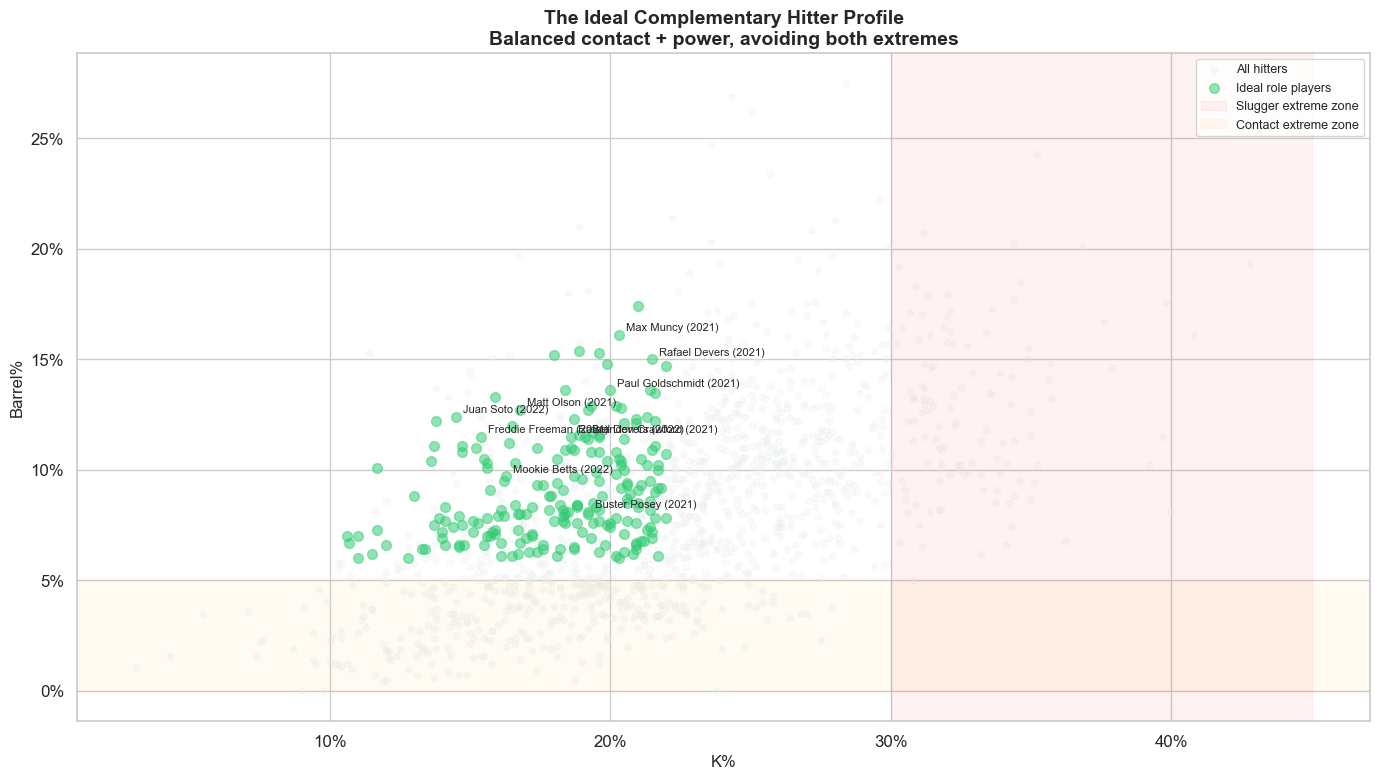

In [8]:
# Figure 2: Role player profile -- show top examples by wOBA
top_role = role_players.sort_values("wOBA", ascending=False).head(30)

fig, ax = plt.subplots(figsize=(14, 8))

# Show top role players vs Gallo/IKF zone
if barrel_col:
    ax.scatter(qualified[k_col], qualified[barrel_col], c="#ecf0f1", s=20, alpha=0.3, label="All hitters")
    ax.scatter(role_players[k_col], role_players[barrel_col], c="#2ecc71", s=50, alpha=0.5, label="Ideal role players")

    # Shade the extremes
    ax.axvspan(0.30, 0.45, alpha=0.05, color="red", label="Slugger extreme zone")
    ax.axhspan(0, 0.05, alpha=0.05, color="orange", label="Contact extreme zone")

    # Label top examples
    for _, row in top_role.head(10).iterrows():
        ax.annotate(f"{row['Name']} ({int(row['Season'])})",
                   (row[k_col], row[barrel_col]),
                   fontsize=8, xytext=(5, 3), textcoords="offset points")

ax.set_xlabel("K%", fontsize=12)
ax.set_ylabel("Barrel%", fontsize=12)
ax.set_title("The Ideal Complementary Hitter Profile\nBalanced contact + power, avoiding both extremes",
             fontsize=14, fontweight="bold")
ax.legend(loc="upper right", fontsize=9)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

plt.tight_layout()
plt.savefig("../outputs/figures/ideal_role_player.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. The Anti-Gallo / Anti-IKF

The point isn't to avoid power or avoid contact. It's to avoid **one without the other**. The middle of the spectrum is where complementary hitters live.

/var/folders/4q/3jg7pd5n5p3cmvkd822n5j240000gn/T/ipykernel_98670/1163857398.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=type_labels, patch_artist=True,


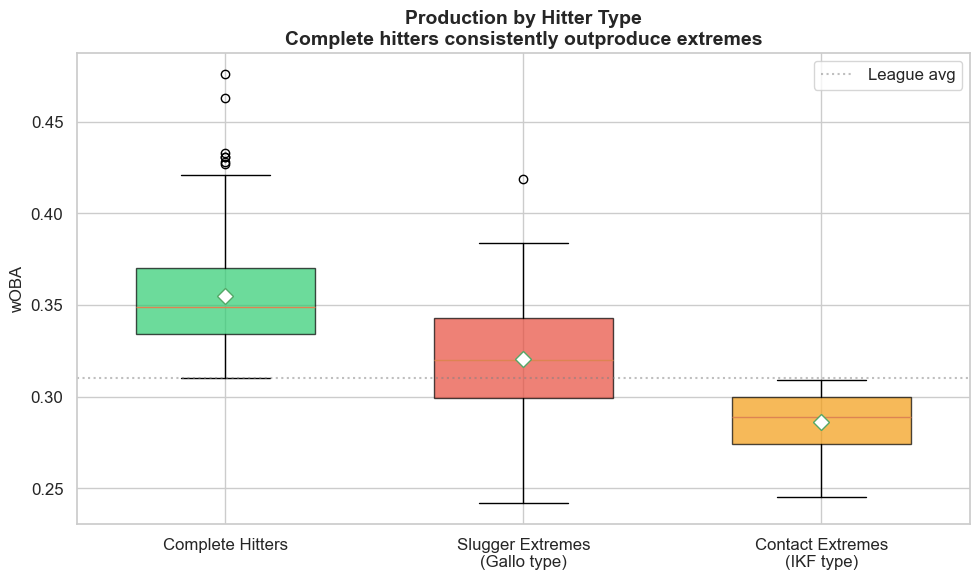

In [9]:
# Figure 3: The extremes vs the middle
# Compare wOBA distributions by hitter type
fig, ax = plt.subplots(figsize=(10, 6))

hitter_types = ["complete", "slugger_extreme", "contact_extreme"]
type_labels = ["Complete Hitters", "Slugger Extremes\n(Gallo type)", "Contact Extremes\n(IKF type)"]
type_colors = ["#2ecc71", "#e74c3c", "#f39c12"]

data_to_plot = []
for htype in hitter_types:
    subset = qualified[qualified["hitter_type"] == htype]["wOBA"].dropna()
    data_to_plot.append(subset)

bp = ax.boxplot(data_to_plot, labels=type_labels, patch_artist=True,
               widths=0.6, showmeans=True,
               meanprops=dict(marker="D", markerfacecolor="white", markersize=8))

for patch, color in zip(bp["boxes"], type_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel("wOBA", fontsize=12)
ax.set_title("Production by Hitter Type\nComplete hitters consistently outproduce extremes",
             fontsize=14, fontweight="bold")
ax.axhline(0.310, color="gray", linestyle=":", alpha=0.5, label="League avg")
ax.legend()

plt.tight_layout()
plt.savefig("../outputs/figures/production_by_type.png", dpi=150, bbox_inches="tight")
plt.show()

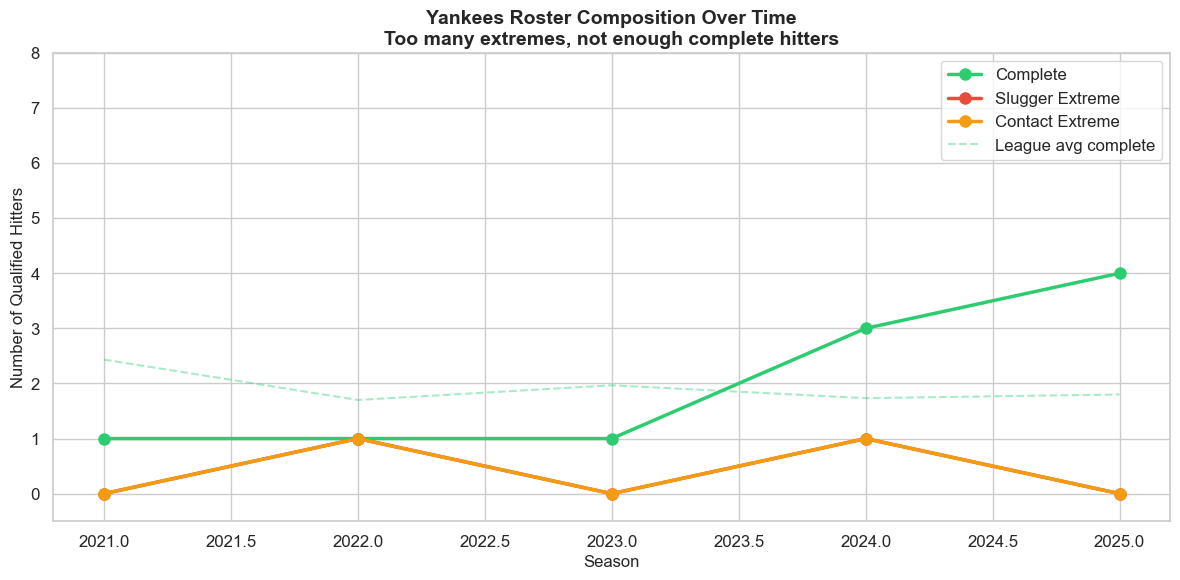

In [10]:
# Figure 4: Yankees roster composition over time
# How many of each type did the Yankees carry each year?
fig, ax = plt.subplots(figsize=(12, 6))

years = sorted(qualified["Season"].unique())
for htype, color, label in [("complete", "#2ecc71", "Complete"),
                              ("slugger_extreme", "#e74c3c", "Slugger Extreme"),
                              ("contact_extreme", "#f39c12", "Contact Extreme")]:
    counts = []
    for year in years:
        yr_qual = qualified[(qualified["Season"] == year) & (qualified["Team"] == "NYY")]
        counts.append(len(yr_qual[yr_qual["hitter_type"] == htype]))
    ax.plot(years, counts, "o-", color=color, linewidth=2.5, markersize=8, label=label)

# Show league average complete hitters per team
league_avg = []
for year in years:
    yr_complete = qualified[(qualified["Season"] == year) & (qualified["hitter_type"] == "complete")]
    league_avg.append(len(yr_complete) / 30)
ax.plot(years, league_avg, "--", color="#2ecc71", alpha=0.4, linewidth=1.5, label="League avg complete")

ax.set_xlabel("Season", fontsize=12)
ax.set_ylabel("Number of Qualified Hitters", fontsize=12)
ax.set_title("Yankees Roster Composition Over Time\nToo many extremes, not enough complete hitters",
             fontsize=14, fontweight="bold")
ax.legend()
ax.set_ylim(-0.5, 8)

plt.tight_layout()
plt.savefig("../outputs/figures/yankees_roster_composition.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. The Baserunning Component

The Dawg metric showed that Hustle (baserunning aggression) independently predicts winning. The ideal role player doesn't just hit — they run the bases. They take the extra bag. They create pressure.

Complete hitters who also run the bases are the most valuable complementary pieces in baseball.

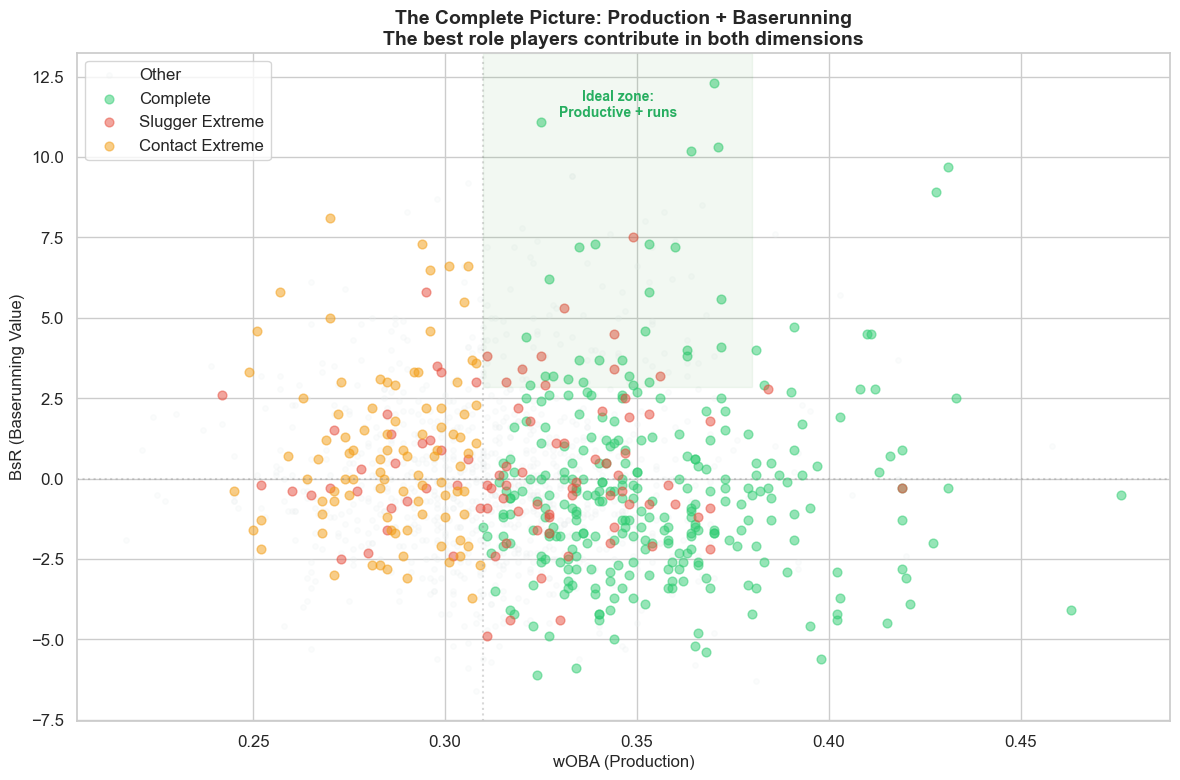

In [11]:
# Figure 5: The full picture -- wOBA vs BsR, colored by hitter type
bsr_col = "BsR" if "BsR" in qualified.columns else None

if bsr_col:
    fig, ax = plt.subplots(figsize=(12, 8))

    for htype, color in [("other", "#ecf0f1"), ("complete", "#2ecc71"),
                          ("slugger_extreme", "#e74c3c"), ("contact_extreme", "#f39c12")]:
        mask = qualified["hitter_type"] == htype
        subset = qualified[mask]
        ax.scatter(subset["wOBA"], subset[bsr_col], c=color, s=40 if htype != "other" else 15,
                  alpha=0.5 if htype != "other" else 0.2,
                  label=htype.replace("_", " ").title() if htype != "other" else "Other")

    # Highlight the ideal quadrant: high wOBA + positive BsR
    ax.axhline(0, color="gray", linestyle=":", alpha=0.3)
    ax.axvline(0.310, color="gray", linestyle=":", alpha=0.3)

    # Shade ideal quadrant
    ax.axvspan(0.310, 0.380, ymin=0.5, ymax=1.0, alpha=0.05, color="green")
    ax.text(0.345, ax.get_ylim()[1] * 0.85, "Ideal zone:\nProductive + runs",
            ha="center", fontsize=10, color="#27ae60", fontweight="bold")

    ax.set_xlabel("wOBA (Production)", fontsize=12)
    ax.set_ylabel("BsR (Baserunning Value)", fontsize=12)
    ax.set_title("The Complete Picture: Production + Baserunning\nThe best role players contribute in both dimensions",
                 fontsize=14, fontweight="bold")
    ax.legend(loc="upper left")

    plt.tight_layout()
    plt.savefig("../outputs/figures/production_vs_baserunning.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("BsR column not found in batting stats. Skipping baserunning analysis.")

## Thesis: Build Complete, Not Extreme

### The recipe

A contending Yankees lineup needs:
1. **1-2 stars** (Judge, Soto-caliber) who carry the offense
2. **3-4 complete hitters** who barrel the ball, take walks, make contact, and run the bases
3. **1-2 specialists** who are genuinely elite at their thing — a speed+defense guy, a power-first platoon bat, a high-OBP table-setter

The key: **specialists are fine as long as the roster is balanced.** You can have a guy who runs and plays elite defense with a lighter bat. You can have a power guy with a little less contact. What you can't do is fill the roster with nothing but one type. The Yankees' mistake wasn't acquiring specialists — it was acquiring *only* extreme sluggers OR *only* no-power contact guys, with nothing in between.

### What they DON'T need
- **Roster-wide extremes**: 3+ hitters who strike out 30%+ of the time OR 3+ hitters who can't barrel anything
- Any hitter whose only plan is "pull everything" OR whose only plan is "slap it oppo"
- The idea that one archetype (power OR contact) is "the answer" — both are tools, neither is a philosophy

### The Ben Rice lesson

Rice is the prototype complete hitter. A lefty who uses the whole field, barrels the ball, takes walks, and happens to play in a park where left-handed power plays up. He's not one-dimensional in any direction. **That's the anchor profile** — then you add specialists around it.

### Connection to Dawg

Complete hitters are also Dawg-positive. They run the bases (Hustle), they produce in leverage situations because they have multiple ways to hurt you (Pressure), and a lineup full of balanced hitters creates more competitive at-bats. The extremes kill Dawg: pure sluggers don't run, contact-only hitters can't come through in big spots. A well-constructed roster with 3-4 complete hitters and smart specialists maximizes all three Dawg components.

## 6. The Roster Blueprint: Archetypes for a Complete Team

Every contending team needs a mix of roles. Not everyone is a star, and not every role player needs the same profile. Here's the mental model:

| Role | Lineup Spots | Key Traits | What They Give Up | Example |
|------|-------------|------------|-------------------|---------|
| **The Star** | 1-2 | Elite in everything | Nothing — they do it all | Judge, Soto |
| **The Complete Hitter** | 3-4 | Barrel + contact + walks + baserunning | Ceiling (they're .310-.350 wOBA, not .400) | The backbone |
| **The Speed/Defense Specialist** | 1 | Elite defense, runs the bases, makes enough contact | Power — sub-5% barrel rate is fine if they're +15 OAA | Harrison Bader type |
| **The Power Platoon** | 1 | Mashes one side (usually LHP), high barrel rate | Contact and playing time — they sit vs same-side arms | Platoon DH |
| **The Table-Setter** | 1 | High OBP, sees pitches, controls the zone | Power — they walk and single, not homer | Leadoff/9-hole catalyst |

The mistake is when 3+ roster spots are filled by the same archetype. Two power platoon bats = fine if you have speed elsewhere. Two speed guys = fine if you have power elsewhere. **Three Gallos or three IKFs = broken.**

In [12]:
# Profile each archetype from the data
# Speed/Defense Specialist: low K%, positive BsR, low barrel is OK
# Power Platoon: high barrel, higher K% acceptable
# Table-Setter: high OBP, high BB%, low power OK

spd_col = "Spd" if "Spd" in qualified.columns else None
def_col = "Def" if "Def" in qualified.columns else None

def classify_role(row):
    barrel = row.get(barrel_col, np.nan) if barrel_col else np.nan
    k_rate = row.get(k_col, np.nan)
    bb_rate = row.get(bb_col, np.nan) if bb_col else np.nan
    woba = row.get("wOBA", np.nan)
    bsr = row.get("BsR", np.nan) if "BsR" in row.index else np.nan
    obp = row.get("OBP", np.nan)

    if pd.isna(k_rate):
        return "unknown"

    # Speed/Defense: low K, positive baserunning, barrel doesn't matter
    if (k_rate <= 0.20 and not pd.isna(bsr) and bsr > 1.0 and
        (woba >= 0.280 if not pd.isna(woba) else True)):
        return "speed_defense"

    # Power Platoon: high barrel, K% up to 30% is acceptable
    if (not pd.isna(barrel) and barrel >= 0.10 and k_rate <= 0.30 and
        (woba >= 0.310 if not pd.isna(woba) else True)):
        return "power_platoon"

    # Table-Setter: high OBP relative to SLG, high BB%
    if (not pd.isna(bb_rate) and bb_rate >= 0.10 and
        not pd.isna(obp) and obp >= 0.330 and k_rate <= 0.22):
        return "table_setter"

    return None  # doesn't fit a specialist role

qualified["specialist_role"] = qualified.apply(classify_role, axis=1)

print("SPECIALIST ROLE PROFILES")
print("=" * 70)

for role, label in [("speed_defense", "Speed/Defense Specialist"),
                     ("power_platoon", "Power Platoon Bat"),
                     ("table_setter", "Table-Setter")]:
    subset = qualified[qualified["specialist_role"] == role]
    print(f"\n{label} (n={len(subset)} player-seasons):")
    
    show_cols = ["Name", "Season", "Team", "wOBA", k_col, "OBP"]
    if barrel_col:
        show_cols.append(barrel_col)
    if "BsR" in qualified.columns:
        show_cols.append("BsR")
    
    available_cols = [c for c in show_cols if c in subset.columns]
    if len(subset) > 0:
        print(subset[available_cols].sort_values("wOBA", ascending=False).head(10).to_string(index=False))
    
    # Average profile
    if len(subset) > 0:
        print(f"\n  Avg profile: wOBA={subset['wOBA'].mean():.3f}, "
              f"K%={subset[k_col].mean():.1%}, "
              f"OBP={subset['OBP'].mean():.3f}"
              + (f", Barrel%={subset[barrel_col].mean():.1%}" if barrel_col else "")
              + (f", BsR={subset['BsR'].mean():.1f}" if "BsR" in subset.columns else ""))

SPECIALIST ROLE PROFILES

Speed/Defense Specialist (n=162 player-seasons):
            Name  Season  Team  wOBA    K%   OBP  Barrel%  BsR
Ronald Acuna Jr.    2023   ATL 0.428 0.114 0.416    0.153  8.9
 Freddie Freeman    2023   LAD 0.411 0.166 0.410    0.111  4.5
  Bobby Witt Jr.    2024   KCR 0.410 0.150 0.389    0.143  4.5
 George Springer    2025   TOR 0.408 0.189 0.399    0.158  2.8
 Freddie Freeman    2022   LAD 0.393 0.144 0.407    0.099  1.7
Christian Yelich    2024   MIL 0.391 0.184 0.406    0.079  4.7
       Juan Soto    2025   NYM 0.390 0.192 0.396    0.181  2.7
     Trea Turner    2021 - - - 0.386 0.170 0.375    0.074  7.6
     Kyle Tucker    2021   HOU 0.383 0.159 0.359    0.116  2.9
 Freddie Freeman    2021   ATL 0.379 0.154 0.393    0.115  1.4

  Avg profile: wOBA=0.328, K%=16.3%, OBP=0.334, Barrel%=5.9%, BsR=3.5

Power Platoon Bat (n=327 player-seasons):
          Name  Season Team  wOBA    K%   OBP  Barrel%  BsR
   Aaron Judge    2024  NYY 0.476 0.243 0.458    0.269 -0.

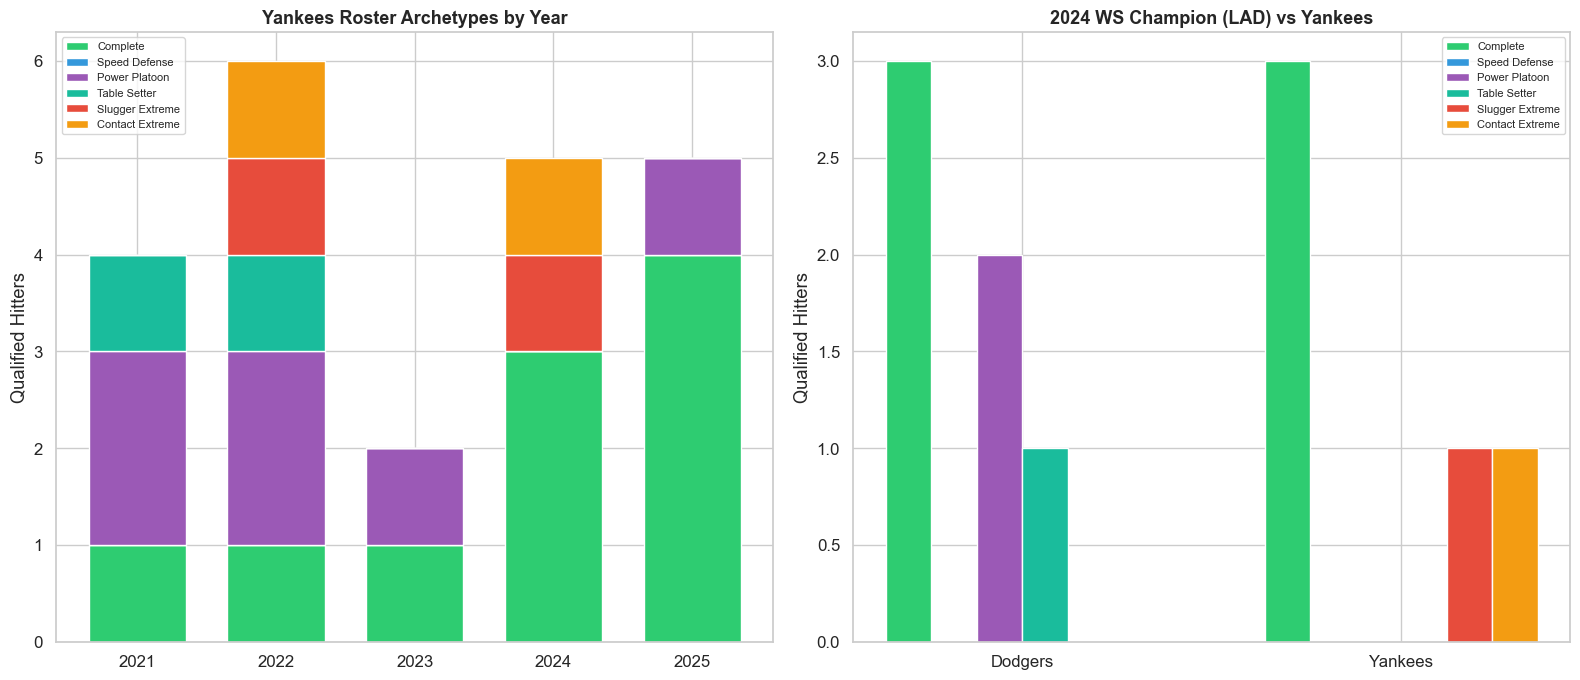

In [13]:
# Figure 6: Yankees vs contenders -- roster archetype breakdown
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Count archetypes per team per year
archetype_order = ["complete", "speed_defense", "power_platoon", "table_setter",
                   "slugger_extreme", "contact_extreme", "other"]
archetype_colors = {
    "complete": "#2ecc71", "speed_defense": "#3498db", "power_platoon": "#9b59b6",
    "table_setter": "#1abc9c", "slugger_extreme": "#e74c3c",
    "contact_extreme": "#f39c12", "other": "#bdc3c7",
}

# Assign specialist role to those who don't have a hitter_type classification
qualified["archetype"] = qualified.apply(
    lambda r: r["specialist_role"] if r["specialist_role"] and r["hitter_type"] == "other"
    else r["hitter_type"], axis=1
)

# Panel 1: Yankees over time
ax = axes[0]
ax.set_title("Yankees Roster Archetypes by Year", fontsize=13, fontweight="bold")
years = sorted(qualified["Season"].unique())

bottom = np.zeros(len(years))
for atype in ["complete", "speed_defense", "power_platoon", "table_setter",
              "slugger_extreme", "contact_extreme"]:
    counts = []
    for year in years:
        yr_nyy = qualified[(qualified["Season"] == year) & (qualified["Team"] == "NYY")]
        counts.append(len(yr_nyy[yr_nyy["archetype"] == atype]))
    ax.bar(years, counts, bottom=bottom, color=archetype_colors.get(atype, "#bdc3c7"),
           label=atype.replace("_", " ").title(), width=0.7)
    bottom += counts

ax.set_ylabel("Qualified Hitters")
ax.legend(fontsize=8, loc="upper left")

# Panel 2: WS winners vs Yankees in most recent year
ax = axes[1]
ax.set_title("2024 WS Champion (LAD) vs Yankees", fontsize=13, fontweight="bold")

teams_to_compare = [("LAD", "Dodgers"), ("NYY", "Yankees")]
x = np.arange(len(teams_to_compare))
width = 0.12

for i, atype in enumerate(["complete", "speed_defense", "power_platoon",
                             "table_setter", "slugger_extreme", "contact_extreme"]):
    vals = []
    for team_abbr, _ in teams_to_compare:
        team_qual = qualified[(qualified["Season"] == 2024) & (qualified["Team"] == team_abbr)]
        vals.append(len(team_qual[team_qual["archetype"] == atype]))
    ax.bar(x + i * width, vals, width, color=archetype_colors.get(atype, "#bdc3c7"),
           label=atype.replace("_", " ").title())

ax.set_xticks(x + width * 2.5)
ax.set_xticklabels([label for _, label in teams_to_compare])
ax.set_ylabel("Qualified Hitters")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("../outputs/figures/roster_archetype_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. 2025 Construction Check: Did the Yankees Improve?

The Yankees entered 2025 after losing the World Series to a Dodgers team that carried 5 complete hitters. Did they adjust their roster construction, or double down on the same formula?

In [14]:
# 2025 Yankees archetype breakdown
nyy_25 = qualified[(qualified["Season"] == 2025) & (qualified["Team"] == "NYY")]

print("2025 YANKEES ARCHETYPE BREAKDOWN (300+ PA)")
print("=" * 60)
for atype in ["complete", "speed_defense", "power_platoon", "table_setter",
              "slugger_extreme", "contact_extreme", "other"]:
    subset = nyy_25[nyy_25["archetype"] == atype]
    if len(subset) > 0:
        print(f"\n{atype.replace('_', ' ').title()} ({len(subset)}):")
        for _, p in subset.iterrows():
            print(f"  {p['Name']}: .{p['wOBA']:.3f}"[:-1] + f" wOBA, "
                  f"{p[k_col]:.1%} K%, "
                  + (f"{p[barrel_col]:.1%} Barrel%, " if barrel_col else "")
                  + f"{p['OBP']:.3f} OBP"
                  + (f", {p['BsR']:.1f} BsR" if 'BsR' in p.index and not pd.isna(p['BsR']) else ""))

# Year-over-year comparison
print("\n\nYANKEES COMPLETE HITTER COUNT BY YEAR")
print("-" * 40)
for year in sorted(qualified["Season"].unique()):
    yr_nyy = qualified[(qualified["Season"] == year) & (qualified["Team"] == "NYY")]
    n_complete = len(yr_nyy[yr_nyy["archetype"] == "complete"])
    n_extreme = len(yr_nyy[yr_nyy["archetype"].isin(["slugger_extreme", "contact_extreme"])])
    total = len(yr_nyy)
    bar = "█" * n_complete + "░" * n_extreme
    print(f"  {year}: {n_complete} complete, {n_extreme} extreme, {total} total  {bar}")

2025 YANKEES ARCHETYPE BREAKDOWN (300+ PA)

Complete (4):
  Aaron Judge: .0.46 wOBA, 23.6% K%, 24.7% Barrel%, 0.457 OBP, -4.1 BsR
  Cody Bellinger: .0.34 wOBA, 13.7% K%, 7.5% Barrel%, 0.334 OBP, 0.9 BsR
  Trent Grisham: .0.35 wOBA, 23.6% K%, 14.2% Barrel%, 0.348 OBP, -3.0 BsR
  Ben Rice: .0.35 wOBA, 18.9% K%, 15.4% Barrel%, 0.337 OBP, -2.0 BsR

Power Platoon (1):
  Jazz Chisholm Jr.: .0.34 wOBA, 27.9% K%, 15.0% Barrel%, 0.332 OBP, 2.9 BsR

Other (4):
  Austin Wells: .0.30 wOBA, 26.3% K%, 10.2% Barrel%, 0.275 OBP, -0.6 BsR
  Anthony Volpe: .0.28 wOBA, 25.2% K%, 10.5% Barrel%, 0.272 OBP, 1.1 BsR
  Paul Goldschmidt: .0.31 wOBA, 18.7% K%, 7.9% Barrel%, 0.328 OBP, -2.6 BsR
  Jasson Dominguez: .0.31 wOBA, 26.8% K%, 7.0% Barrel%, 0.331 OBP, 3.0 BsR


YANKEES COMPLETE HITTER COUNT BY YEAR
----------------------------------------
  2021: 1 complete, 0 extreme, 8 total  █
  2022: 1 complete, 2 extreme, 9 total  █░░
  2023: 1 complete, 0 extreme, 8 total  █
  2024: 3 complete, 2 extreme, 9 total 

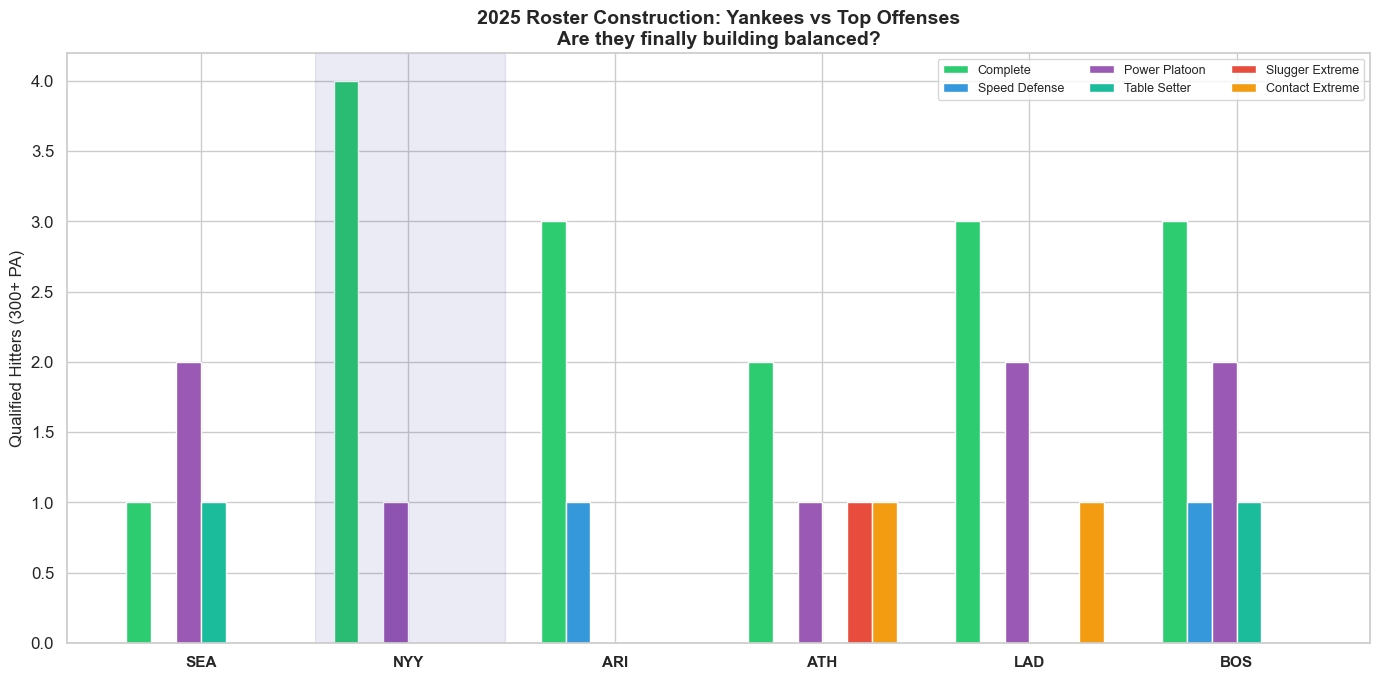

In [15]:
# Figure 7: 2025 Yankees vs top 2025 teams by archetype distribution
# Identify top teams by win% (use wRC+ as proxy if W not available)
teams_25 = qualified[qualified["Season"] == 2025].groupby("Team").agg(
    n_hitters=("Name", "count"),
    avg_wOBA=("wOBA", "mean"),
    n_complete=("archetype", lambda x: (x == "complete").sum()),
    n_extreme=("archetype", lambda x: x.isin(["slugger_extreme", "contact_extreme"]).sum()),
).sort_values("avg_wOBA", ascending=False)

# Take top 6 teams + ensure NYY is included
top_teams = list(teams_25.head(6).index)
if "NYY" not in top_teams:
    top_teams.append("NYY")

fig, ax = plt.subplots(figsize=(14, 7))

bar_width = 0.12
x = np.arange(len(top_teams))
archetypes_to_show = ["complete", "speed_defense", "power_platoon",
                       "table_setter", "slugger_extreme", "contact_extreme"]

for i, atype in enumerate(archetypes_to_show):
    vals = []
    for team in top_teams:
        team_q = qualified[(qualified["Season"] == 2025) & (qualified["Team"] == team)]
        vals.append(len(team_q[team_q["archetype"] == atype]))
    bars = ax.bar(x + i * bar_width, vals, bar_width,
                  color=archetype_colors.get(atype, "#bdc3c7"),
                  label=atype.replace("_", " ").title())

# Highlight NYY
nyy_idx = top_teams.index("NYY")
ax.axvspan(nyy_idx - 0.15, nyy_idx + len(archetypes_to_show) * bar_width + 0.05,
           alpha=0.08, color="navy")

ax.set_xticks(x + bar_width * 2.5)
ax.set_xticklabels(top_teams, fontsize=11, fontweight="bold")
ax.set_ylabel("Qualified Hitters (300+ PA)", fontsize=12)
ax.set_title("2025 Roster Construction: Yankees vs Top Offenses\nAre they finally building balanced?",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=9, ncol=3, loc="upper right")

plt.tight_layout()
plt.savefig("../outputs/figures/2025_construction_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### 2025 Assessment

The numbers tell the story. Compare the 2025 Yankees archetype distribution to prior years:
- Did they add complete hitters?
- Did they reduce the extremes?
- How do they stack up against the best teams in baseball?

The answers feed directly into the next analysis: **what should the ideal 1-9 lineup look like**, and where does the 2025 Yankees roster fit that model?